# React Agent with LangGraph

In [ ]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")

In [ ]:
!pip install langchain_openrouter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 14.6 MB/s eta 0:00:00


In [ ]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="openai/gpt-oss-20b:free",
#     temperature=0.8,
# )


In [ ]:
import os

In [ ]:
from langgraph.graph import MessagesState, StateGraph, END, START
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import display, Image
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/tmp/ipykernel_1984/3638340991.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b

In [ ]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

In [ ]:
from langchain_core.tools import tool

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [ ]:
!pip install ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 51.5 MB/s eta 0:00:00


In [ ]:
!pip install duckduckgo-search

In [ ]:
search = DuckDuckGoSearchRun()

In [ ]:
search.invoke("Who is current President of Iran?")

"8 hours ago - The president is elected for a four-year term in a national election by universal adult suffrage by Iranians of at least 18 years of age, and can only be reelected once if in a consecutive manner. Candidates for the presidency must be approved by the Guardian Council. Masoud Pezeshkian is currently ... 1 day ago - After taking office, Pezeshkian retained Mohammad Eslami as vice president and head of the Atomic Energy Organization, while appointing the former first vice president of Iran Mohammad Reza Aref and former vice president and head of the Foundation of Martyrs and Veterans Affairs Saeed Ohadi back to their posts, in addition to appointing former education minister Mohsen Haji-Mirzaei as his chief of staff, former foreign minister Mohammad Javad Zarif as vice president for Strategic Affairs, Mohammad Ja'far Ghae'em Panah as vice president for Executive Affairs, former finance minister Ali Tayebni April 16, 2026 - The president of Iran is the highest popularly elec

In [ ]:
tools = [add, multiply, divide, search]

In [ ]:
llm_with_tools=llm.bind_tools(tools)

In [ ]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

In [ ]:
def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [ ]:
# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)

builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")

builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

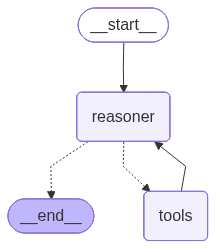

In [ ]:
# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="What is 2 times of Donald Trump age?")]

In [ ]:
messages = react_graph.invoke({"messages": messages})

In [ ]:
for m in messages['messages']:
  m.pretty_print()

================================ Human Message =================================

What is 2 times of Donald Trump age?
================================== Ai Message ==================================

To determine Donald Trump's age, I need to look up his birthdate.
Tool Calls:
  duckduckgo_search (j0g5xvp1z)
 Call ID: j0g5xvp1z
  Args:
    query: Donald Trump age
================================= Tool Message =================================
Name: duckduckgo_search

Donald John Trump was born at Jamaica Hospital Medical Center in Queens, New York City. [1] He is the son of Fred Trump and his wife Mary Anne (née MacLeod). They married in 1936. His mother was born on the Isle of Lewis, off the west coast of Scotland. [2] Donald was one of five children. [3] Donald's oldest brother, Fred Jr., died in 1981 at the age of 43, due to an alcohol addiction. [4 ... Donald Trump is the 45th and 47th president of the United States (2017-21; 2025- ). Following his inauguration on January 20, 2025

In [ ]:
messages = [HumanMessage(content="What is the result when you add 100 years to the age of Jack Ma, who is famous business personality of China?")]

In [ ]:
messages = react_graph.invoke({"messages": messages})

TypeError: can only concatenate list (not "dict") to list

In [ ]:
for m in messages['messages']:
  m.pretty_print()

================================ Human Message =================================

What is the result when you add 100 years to the age of Jack Ma, who is famous business personality of China?
================================== Ai Message ==================================

To calculate the result, I need to find Jack Ma's current age.
Tool Calls:
  duckduckgo_search (p5q6pnmd6)
 Call ID: p5q6pnmd6
  Args:
    query: Jack Ma age
================================= Tool Message =================================
Name: duckduckgo_search

Ma was born in Hangzhou, Zhejiang, on 10 September 1964. [3] He became interested in learning the English language as a young boy and began practicing it with English-speaking visitors who frequented the Hangzhou International Hotel. At the age of 12, Ma bought a pocket radio and began listening to English radio stations frequently. Jack Ma is #83 on Forbes' 2026 Billionaires list. Read more about Jack Ma, their experience, their asset summary, and more here

In [ ]:
import yfinance as yf

def get_stock_price(ticker: str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock = yf.Ticker(ticker)
    return stock.info['previousClose']

In [ ]:
get_stock_price("BABA")

131.47

In [ ]:
# Node
def reasoner(state):
    query = state["query"]
    messages = state["messages"]
    # System message
    sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs.")
    message = HumanMessage(content=query)
    messages.append(message)
    result = [llm_with_tools.invoke([sys_msg] + messages)]
    return {"messages":result}

In [ ]:
tools = [add, multiply, divide, search, get_stock_price]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [ ]:
class GraphState(TypedDict):
  query: str
  finance: str
  final_answer: str
  # intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]
  messages: Annotated[list[AnyMessage], operator.add]

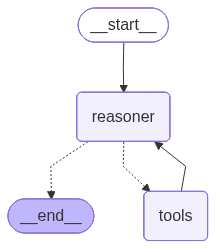

In [ ]:
# Graph
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("reasoner", reasoner)
workflow.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
workflow.add_edge(START, "reasoner")

workflow.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)

workflow.add_edge("tools", "reasoner")
react_graph = workflow.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
response = react_graph.invoke({"query": "What is the stock price of Ali Baba add 1000?", "messages": []})

In [ ]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the stock price of Ali Baba add 1000?
================================== Ai Message ==================================

First I need to get the current stock price of Alibaba. Then I can add 1000 to it.

The ticker symbol for Alibaba is BABA. I will use the get_stock_price function to retrieve the current stock price.
Tool Calls:
  get_stock_price (4ze50dcfh)
 Call ID: 4ze50dcfh
  Args:
    ticker: BABA
================================= Tool Message =================================
Name: get_stock_price

131.47
================================ Human Message =================================

What is the stock price of Ali Baba add 1000?
================================== Ai Message ==================================

The stock price of Alibaba (BABA) is $131.47. Adding 1000 to this price gives $1131.47.
